In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv("Telco-Customer-Churn.csv")
print(data)


      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges  are recorded

In [4]:
data["TotalCharges"]=data["TotalCharges"].replace(" ","0")
data["TotalCharges"]=data["TotalCharges"].astype("float")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
data.isnull().sum().sum()

np.int64(0)

In [7]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
data["customerID"].duplicated().sum()

np.int64(0)

In [9]:
def conv(value):
    if value==1:
        return "yes"
    else:
        return "no"
data["SeniorCitizen"]=data["SeniorCitizen"].apply(conv)

#converted 1 & 0 values of Senior citizen to yes & no to make it easier to understand 

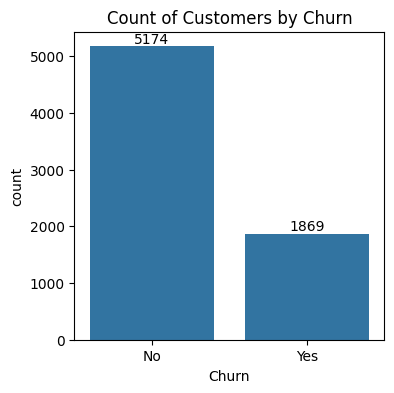

In [10]:
plt.figure(figsize=(4,4))
a=sns.countplot(data=data,x="Churn")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Count of Customers by Churn")
plt.show()

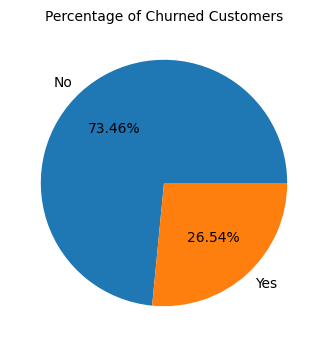

In [11]:
plt.figure(figsize=(4,4))
gb=data.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb["Churn"],autopct="%1.2f%%",labels=gb.index)
plt.title("Percentage of Churned Customers",fontsize=10)
plt.show()

#from the above pie chart we can say that 26.54% customers have churned out
#now lets explore the reason behind it

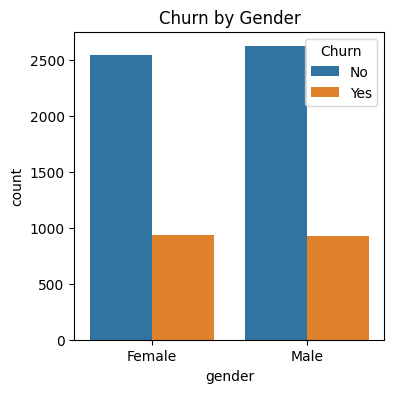

In [12]:
plt.figure(figsize=(4,4))
sns.countplot(data=data,x="gender",hue="Churn")
plt.title("Churn by Gender")
plt.show()

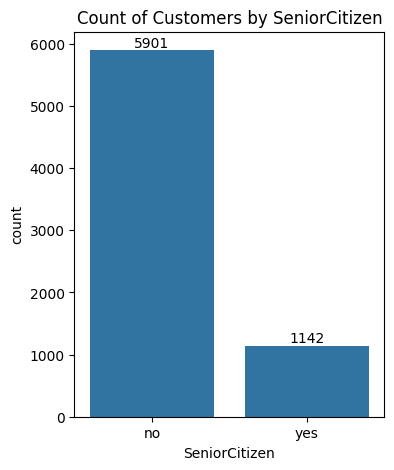

In [13]:
plt.figure(figsize=(4,5))
a=sns.countplot(data=data,x="SeniorCitizen")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Count of Customers by SeniorCitizen")
plt.show()

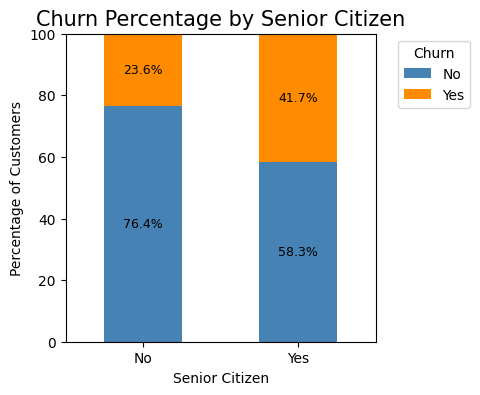

<Figure size 400x400 with 0 Axes>

In [14]:
counts = pd.crosstab(data['SeniorCitizen'], data['Churn'])
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(4, 4))
bars = percentages.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'darkorange'])
for i, row in enumerate(percentages.values):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 0:
            ax.text(i, cumulative + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=9)
            cumulative += val
ax.set_title('Churn Percentage by Senior Citizen',fontsize=15)
ax.set_xlabel('Senior Citizen')
ax.set_ylabel('Percentage of Customers')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'],rotation=0)
ax.set_ylim(0, 100)
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.figure(figsize=(4,4))
plt.tight_layout()
plt.show()

#comparatively a greater percentage of people in senior citizen category have churned.

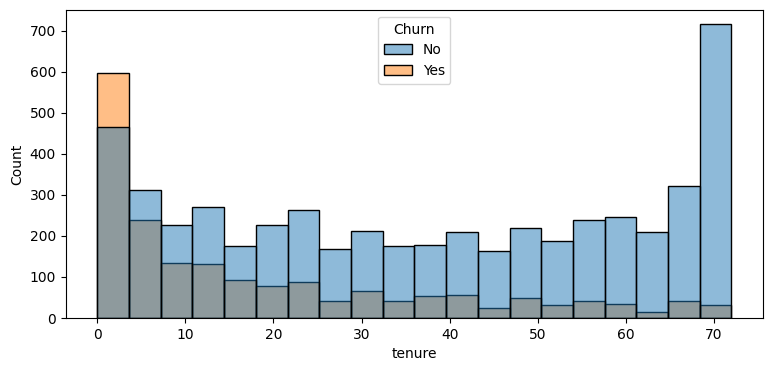

In [15]:
plt.figure(figsize=(9,4))
sns.histplot(data=data,x="tenure",bins=20,hue="Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services for 1 or 2 months have churned.

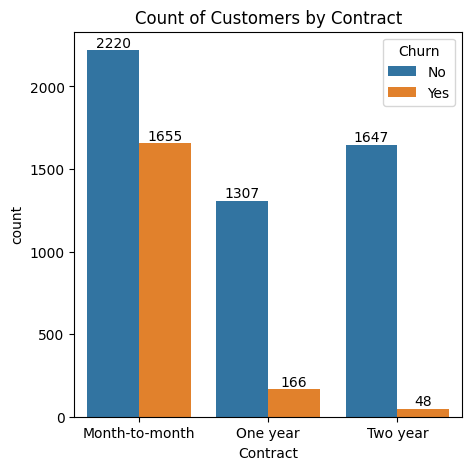

In [16]:
plt.figure(figsize=(5,5))
a=sns.countplot(data=data,x="Contract",hue="Churn")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Count of Customers by Contract")
plt.show()

#people who have month-to-month contract have churned out more than the people who have 1 or 2 years of contract.

In [17]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

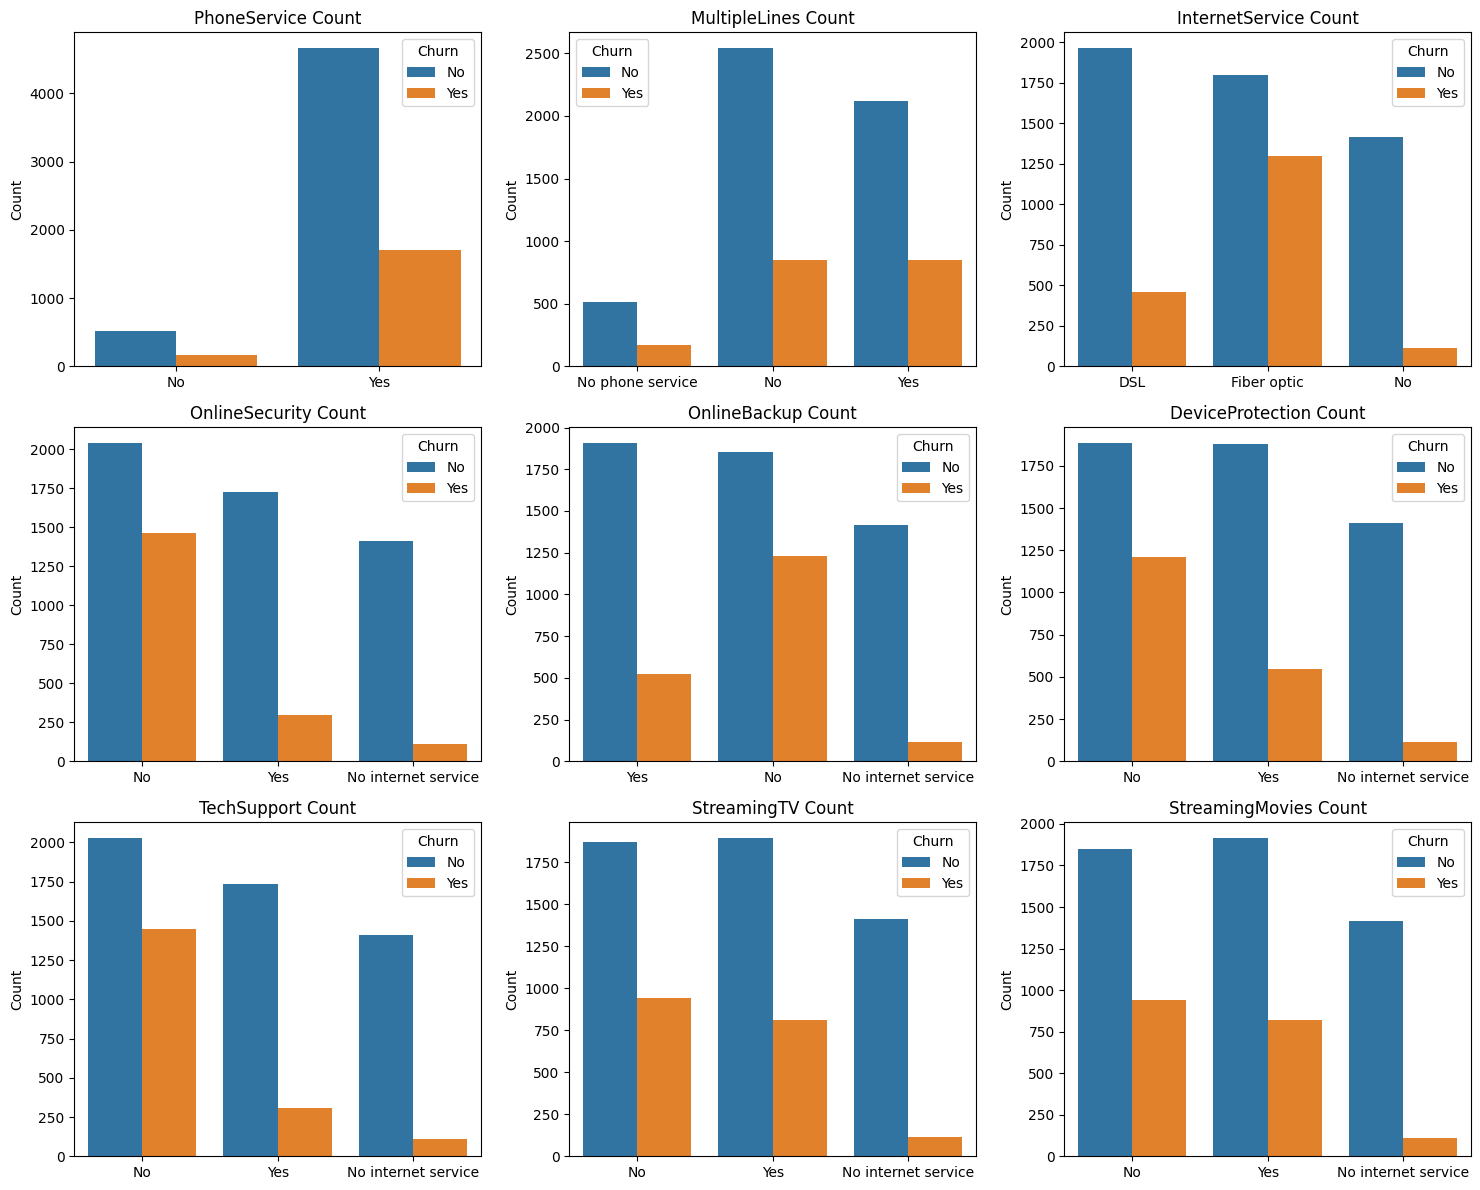

In [18]:
features = ['PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

# Set up the subplot grid (3 rows x 3 columns for 9 plots)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

# Loop through features and axes
for i, col in enumerate(features):
    sns.countplot(data=data, x=col, ax=axes[i],hue="Churn")
    axes[i].set_title(f'{col} Count')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

#This set of subplots shows the relationship between various telecom services and customer churn. Overall, customers with services like Fiber optic internet, OnlineSecurity, TechSupport, and StreamingTV tend to have higher churn rates compared to those without. Also, having no internet service or no phone service is generally linked with lower churn.

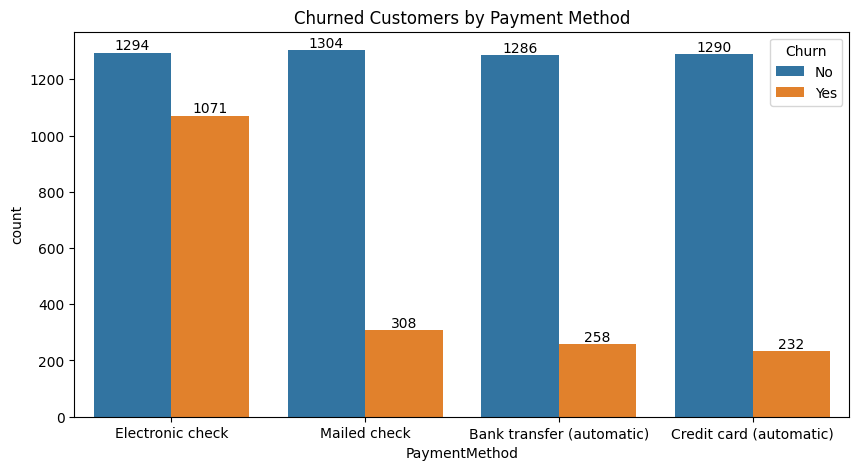

In [127]:
plt.figure(figsize=(10,5))
a=sns.countplot(data=data,x="PaymentMethod",hue="Churn")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Churned Customers by Payment Method")
plt.show()

#A customer is likely to churn when he is using electronic check as a payment method.

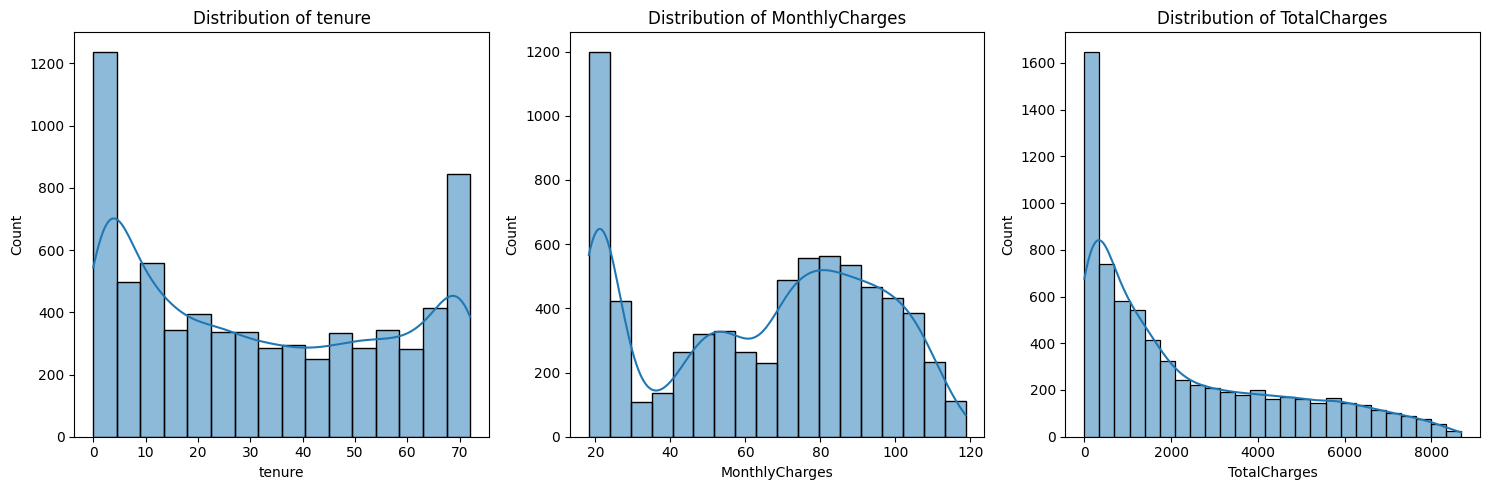

In [24]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

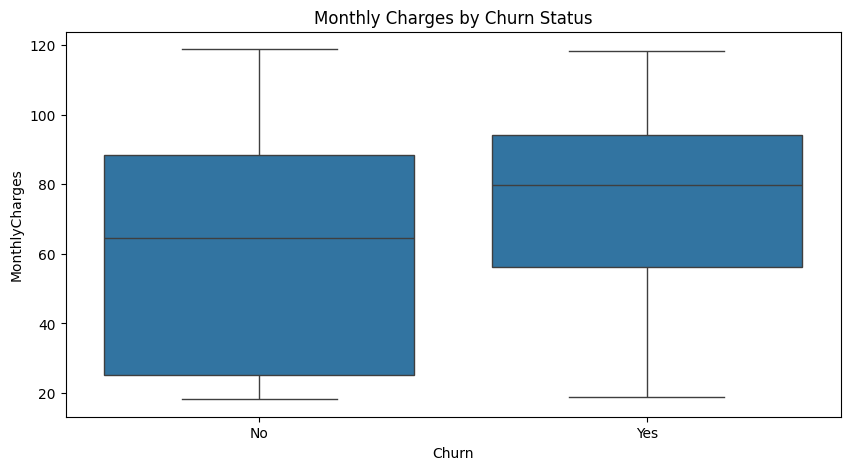

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.show()

In [28]:
churn_rates = data.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()
print(churn_rates)

Churn                No       Yes
SeniorCitizen                    
no             0.763938  0.236062
yes            0.583187  0.416813


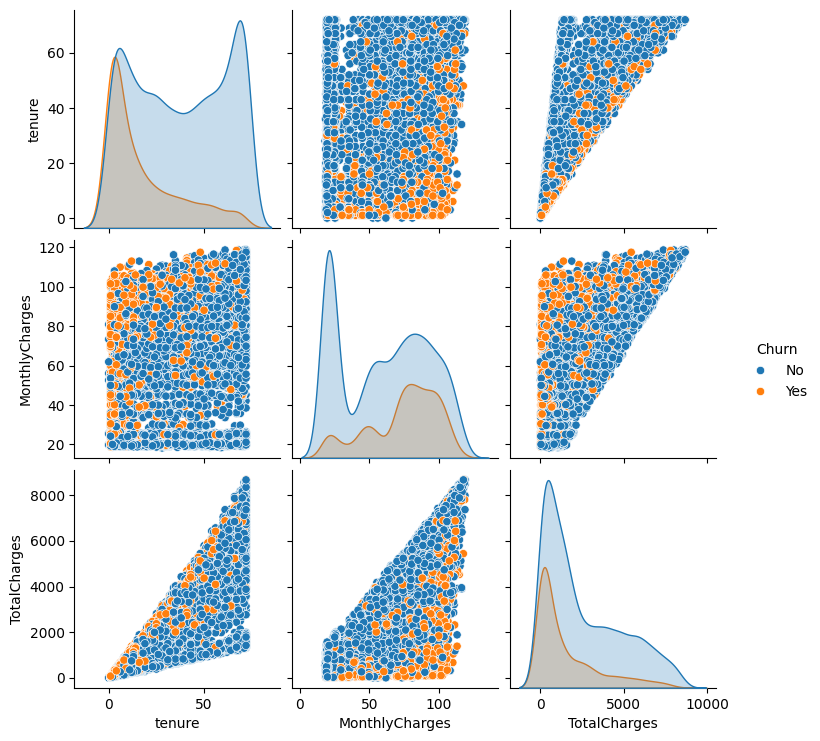

In [29]:
sns.pairplot(data[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], hue='Churn')
plt.show()

<Figure size 1000x500 with 0 Axes>

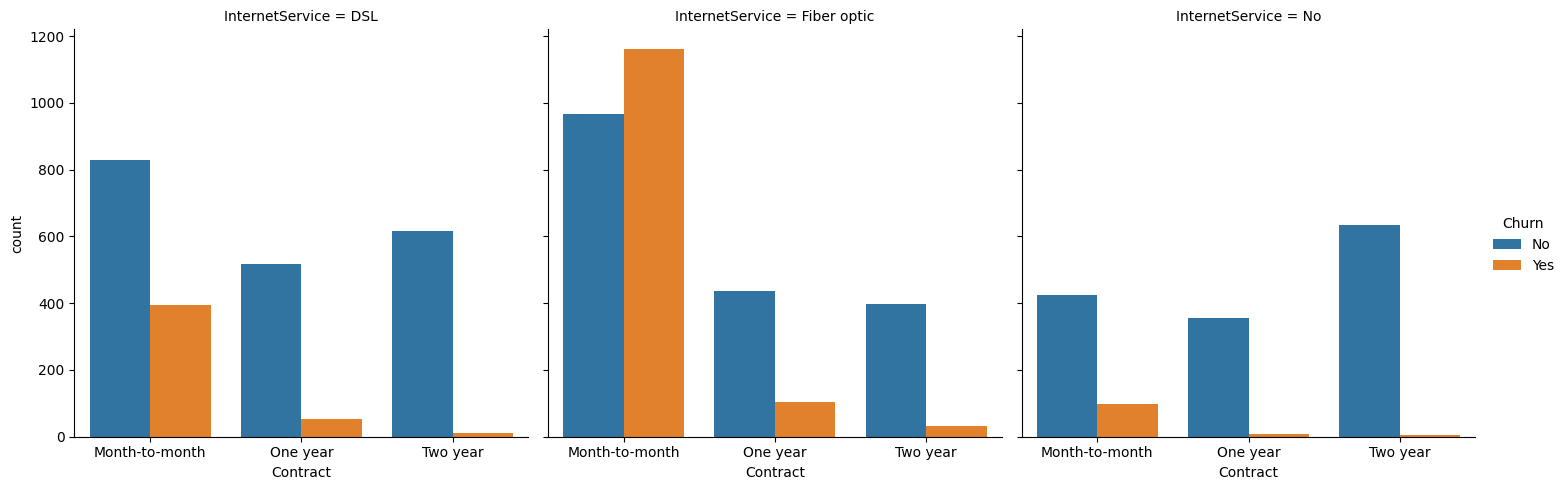

In [30]:
plt.figure(figsize=(10, 5))
sns.catplot(data=data, x='Contract', hue='Churn', col='InternetService', kind='count')
plt.show()

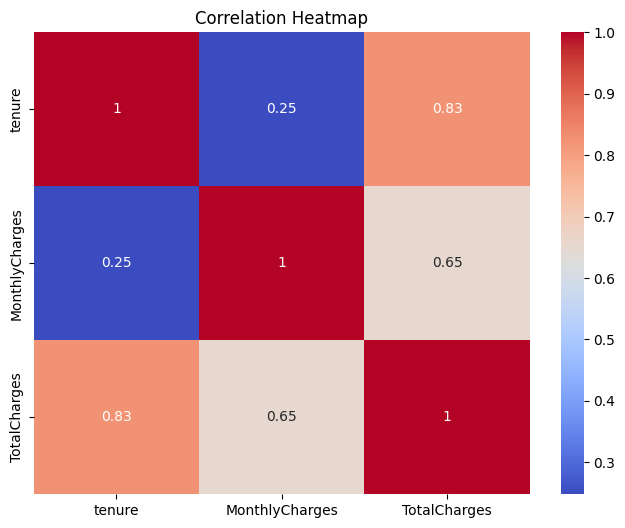

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

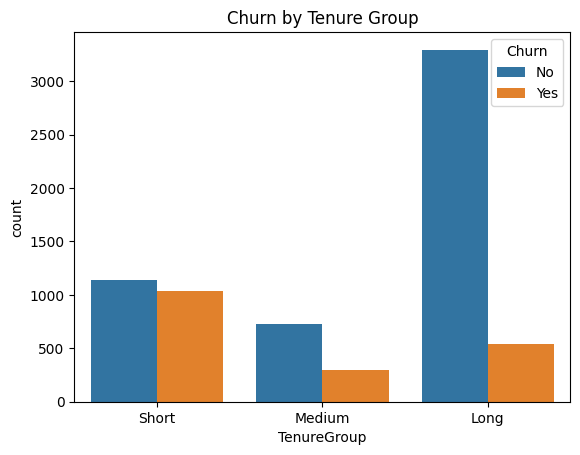

In [35]:
data['TenureGroup'] = pd.cut(data['tenure'], bins=[0, 12, 24, 72], labels=['Short', 'Medium', 'Long'])
sns.countplot(data=data, x='TenureGroup', hue='Churn')
plt.title('Churn by Tenure Group')
plt.show()

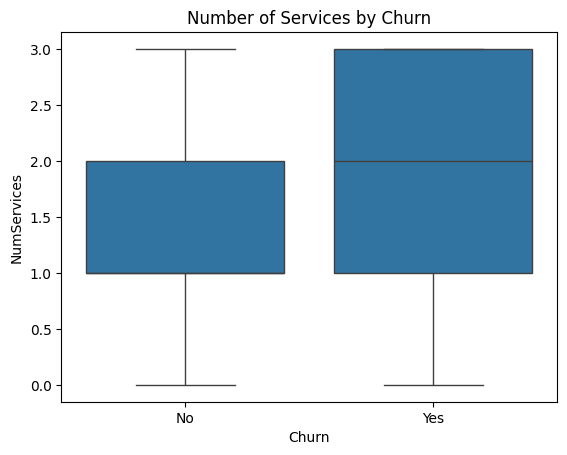

In [36]:
data['NumServices'] = data[['PhoneService', 'InternetService', 'StreamingTV', 'StreamingMovies']].eq('Yes').sum(axis=1)
sns.boxplot(data=data, x='Churn', y='NumServices')
plt.title('Number of Services by Churn')
plt.show()

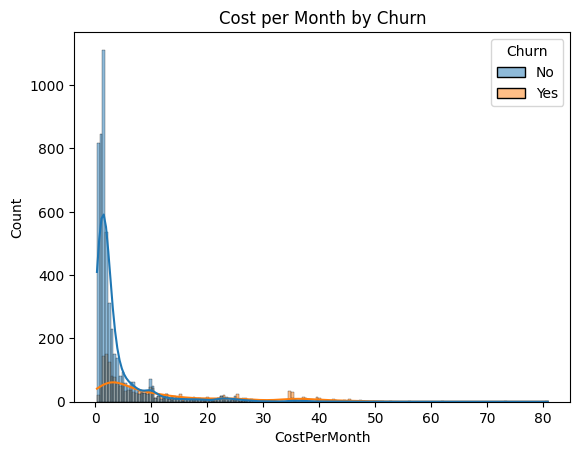

In [37]:
data['CostPerMonth'] = data['MonthlyCharges'] / (data['tenure'] + 1)  # Add 1 to avoid division by zero
sns.histplot(data=data, x='CostPerMonth', hue='Churn', kde=True)
plt.title('Cost per Month by Churn')
plt.show()

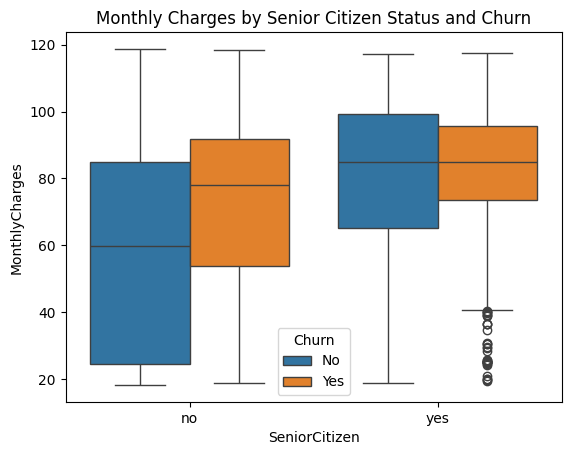

In [38]:
sns.boxplot(data=data, x='SeniorCitizen', y='MonthlyCharges', hue='Churn')
plt.title('Monthly Charges by Senior Citizen Status and Churn')
plt.show()